# Exploring the wPCC Vessel Manoeuvring Data

This notebook demonstrates how to:

1. Load raw test data and ship properties
2. Visualize manoeuvring tests (turning circles, zigzag)
3. Load Kalman-filtered/smoothed data (after running the pipeline)
4. Compare raw vs smoothed signals
5. Work with the Kedro catalog programmatically

**Run `setup.sh` first**, then run the pipeline:

```bash
PYTHONPATH=src:$PYTHONPATH python3 -m wPCC_pipeline --pipeline wpcc
```


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# Project root (one level up from notebooks/)
ROOT = (
    os.path.join(os.path.dirname(os.getcwd()), "")
    if os.path.basename(os.getcwd()) == "notebooks"
    else ""
)
RAW = os.path.join(ROOT, "data/01_raw/wpcc")
INTERMEDIATE = os.path.join(ROOT, "data/02_intermediate/wpcc")
PRIMARY = os.path.join(ROOT, "data/03_primary/wpcc")

## 1. Ship Properties

The wPCC (wind-powered car carrier) model ship — a 5m hull tested at SSPA.


In [14]:
with open(os.path.join(RAW, "ship_data.yml")) as f:
    ship_data = yaml.safe_load(f)

print(f"Ship length (Lpp):  {ship_data['L']:.3f} m")
print(f"Beam (B):           {ship_data['B']:.3f} m")
print(f"Draft (T):          {ship_data['T']:.3f} m")
print(f"Mass:               {ship_data['m']:.1f} kg")
print(f"Block coefficient:  {ship_data['CB']:.3f}")
print(f"Propeller diameter: {ship_data['D']:.3f} m")
print(f"Twin screw:         {'Yes' if ship_data.get('TWIN') else 'No'}")
print(f"Yaw inertia (Iz):   {ship_data['I_z']:.1f} kg·m²")

Ship length (Lpp):  5.015 m
Beam (B):           0.947 m
Draft (T):          0.206 m
Mass:               441.0 kg
Block coefficient:  0.450
Propeller diameter: 0.121 m
Twin screw:         Yes
Yaw inertia (Iz):   742.0 kg·m²


## 2. Available Test Runs


In [15]:
runs_meta = pd.read_csv(os.path.join(RAW, "runs_meta_data.csv"), index_col=0)
runs_meta

/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


,ship_speed,comment,test_type,angle1
22635,0.801475,10.0 kn,reference speed,NaN
22611,0.961770,12.0 kn,reference speed,NaN
22639,0.641180,8.0 kn,reference speed,NaN
22765,0.961770,ZZ 10/10PS,zigzag,10.0
22770,0.961770,ZZ 10/10PS,zigzag,10.0
22773,0.961770,ZZ 20/20PS,zigzag,20.0
22772,0.961770,ZZ 20/20SB,zigzag,20.0


## 3. Load & Plot Raw Test Data

Each CSV has time-series from the model test: positions (x0, y0), heading (psi), rudder angle (delta), propeller RPM/thrust, and accelerometers.


In [16]:
# Load all available test runs
test_ids = [str(i) for i in runs_meta.index]
runs = {}
for tid in test_ids:
    path = os.path.join(RAW, f"{tid}.csv")
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["t"] = df["time"] - df["time"].iloc[0]  # zero-based time
        runs[tid] = df

print(f"Loaded {len(runs)} test runs: {list(runs.keys())}")

Loaded 7 test runs: ['22635', '22611', '22639', '22765', '22770', '22773', '22772']


### 3a. Ship Tracks (Bird's Eye View)

Plot the trajectory of each test — turning circles show circular arcs, zigzags show alternating heading changes.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1846: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])  # type: ignore[arg-type]
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1846: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])  # type: ignore[arg-type]
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/s

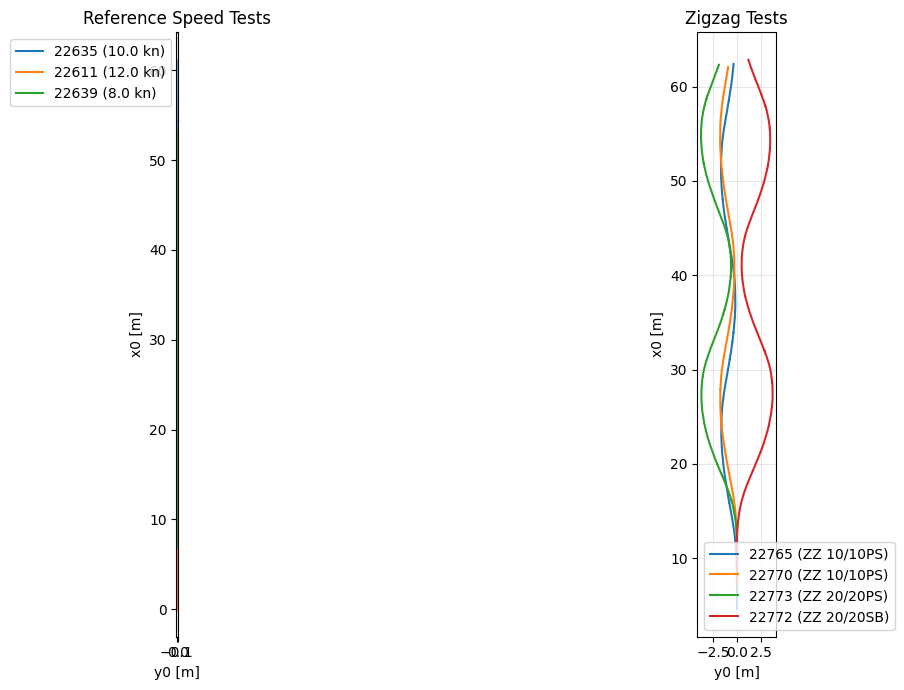

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Reference speed tests (turning circles)
ax = axes[0]
for tid, df in runs.items():
    meta = runs_meta.loc[int(tid)]
    if meta["test_type"] == "reference speed":
        ax.plot(df["y0"], df["x0"], label=f"{tid} ({meta['comment']})")
ax.set_xlabel("y0 [m]")
ax.set_ylabel("x0 [m]")
# ax.set_title("Turning Circle Tests")
ax.set_title("Reference Speed Tests")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Zigzag tests
ax = axes[1]
for tid, df in runs.items():
    meta = runs_meta.loc[int(tid)]
    if meta["test_type"] == "zigzag":
        ax.plot(df["y0"], df["x0"], label=f"{tid} ({meta['comment']})")
ax.set_xlabel("y0 [m]")
ax.set_ylabel("x0 [m]")
ax.set_title("Zigzag Tests")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3b. Zigzag Test Time Histories

The classic zigzag manoeuvre: the rudder alternates between port and starboard while the ship oscillates in heading.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1846: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])  # type: ignore[arg-type]


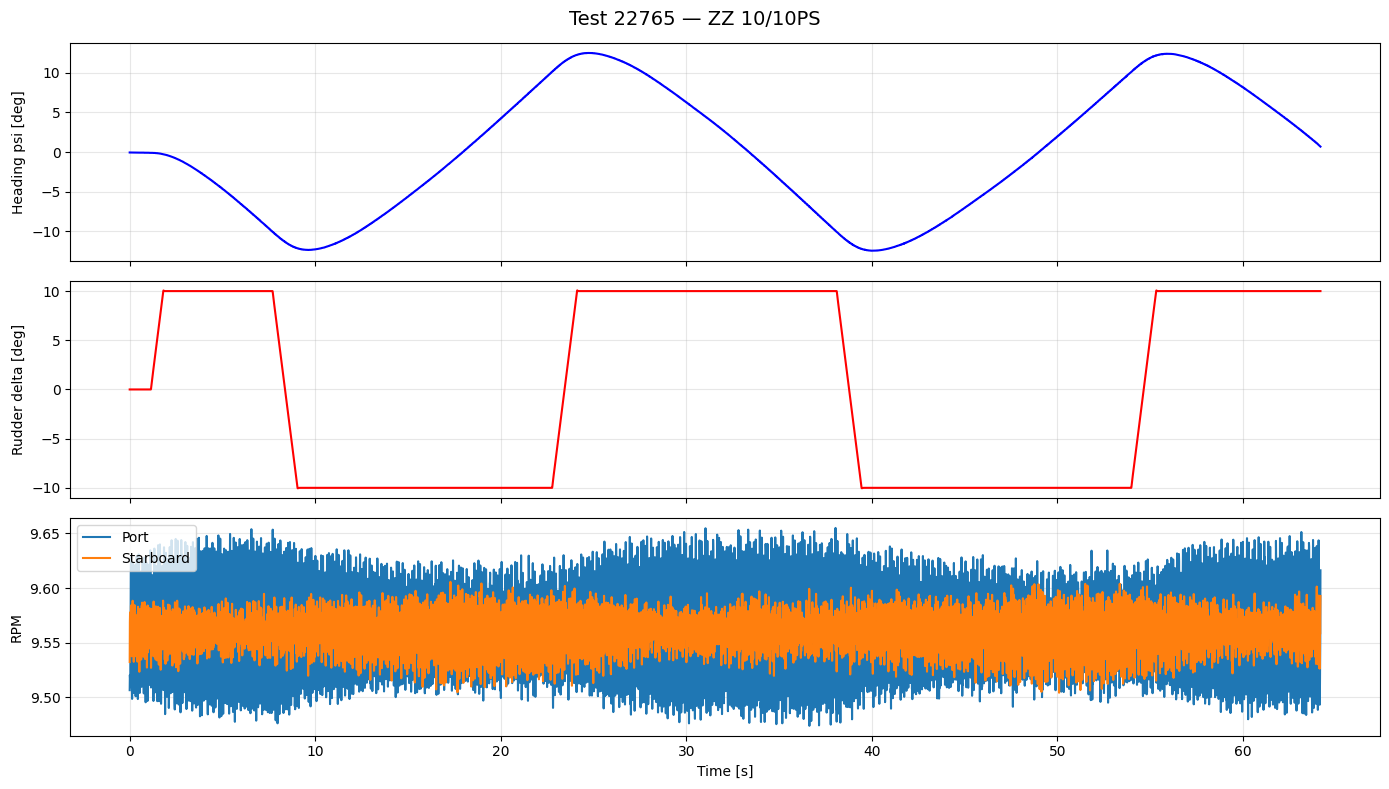

/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1846: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])  # type: ignore[arg-type]


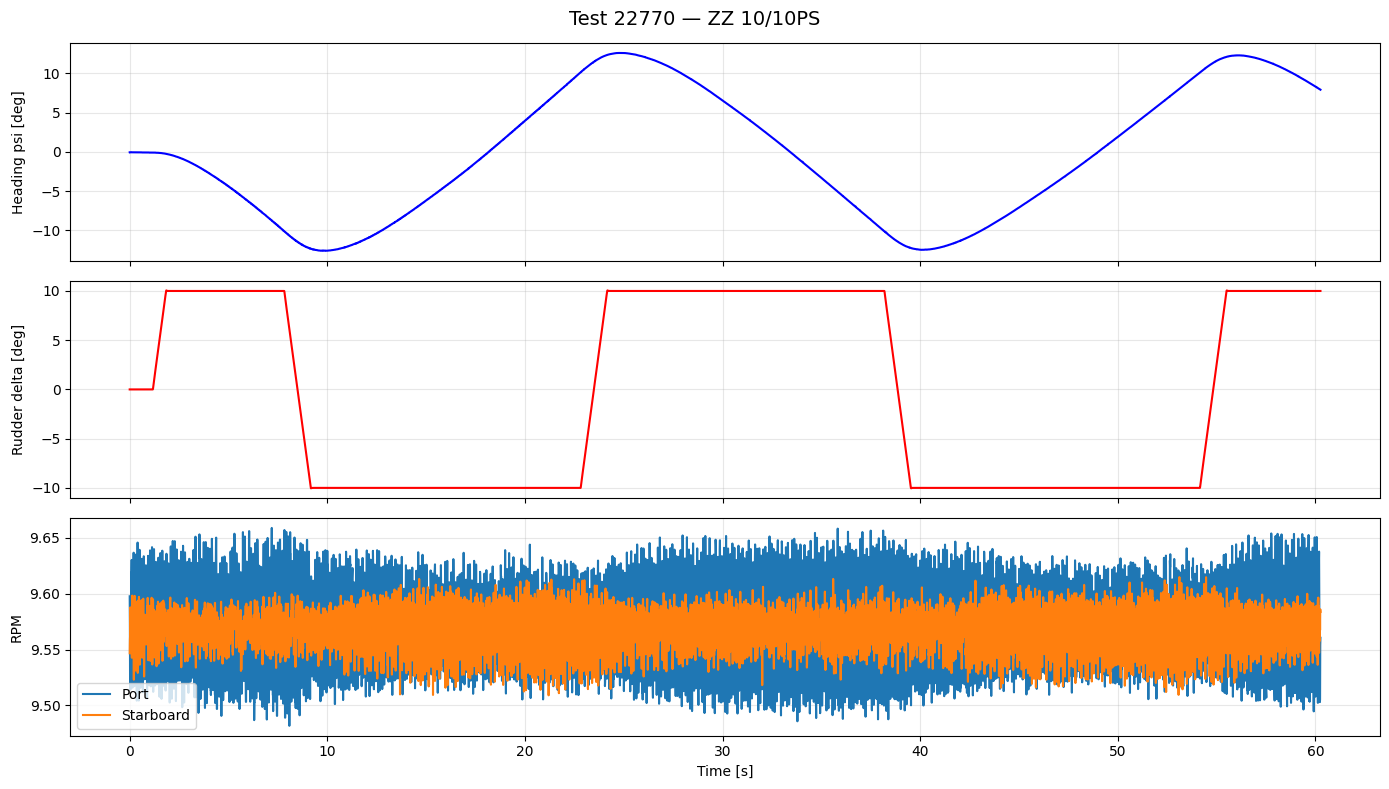

/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1846: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])  # type: ignore[arg-type]


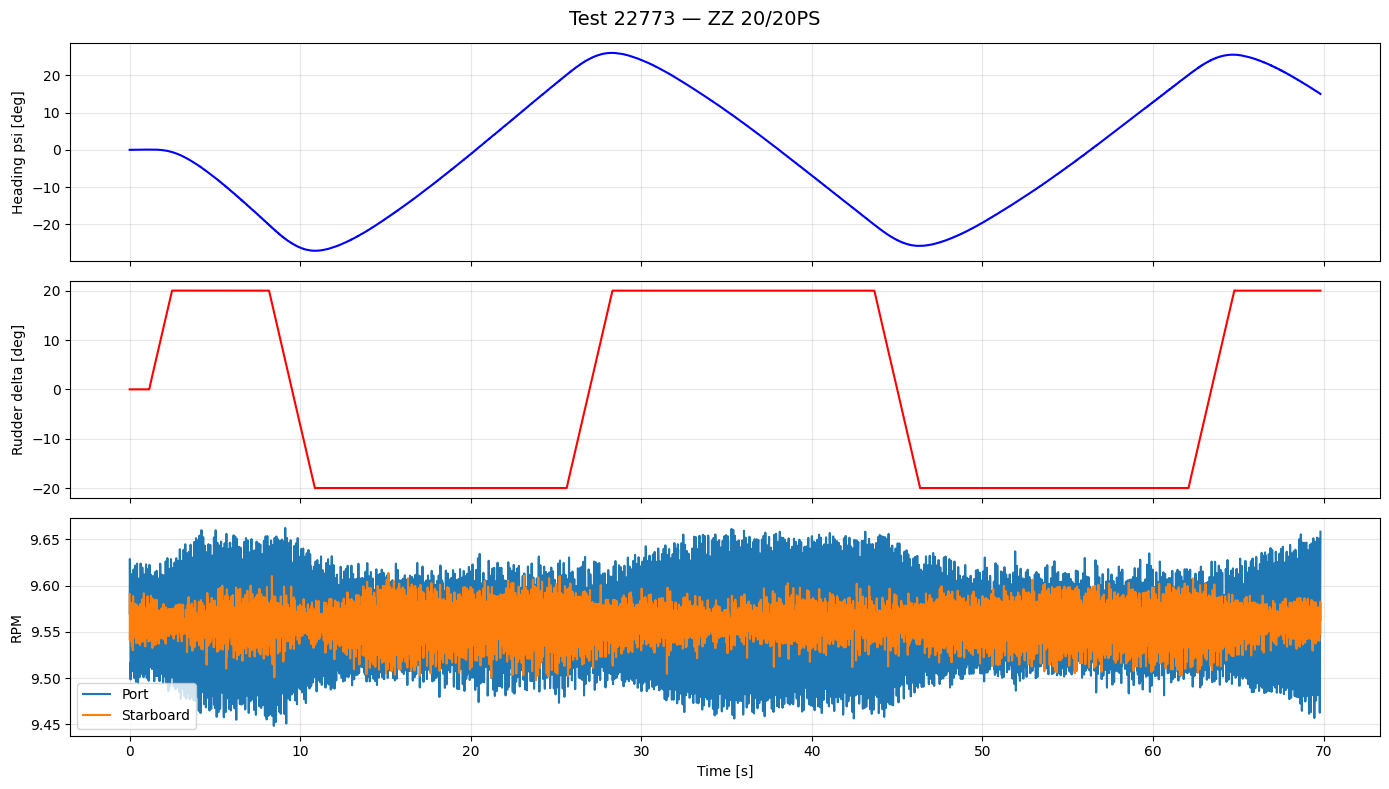

/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1846: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])  # type: ignore[arg-type]


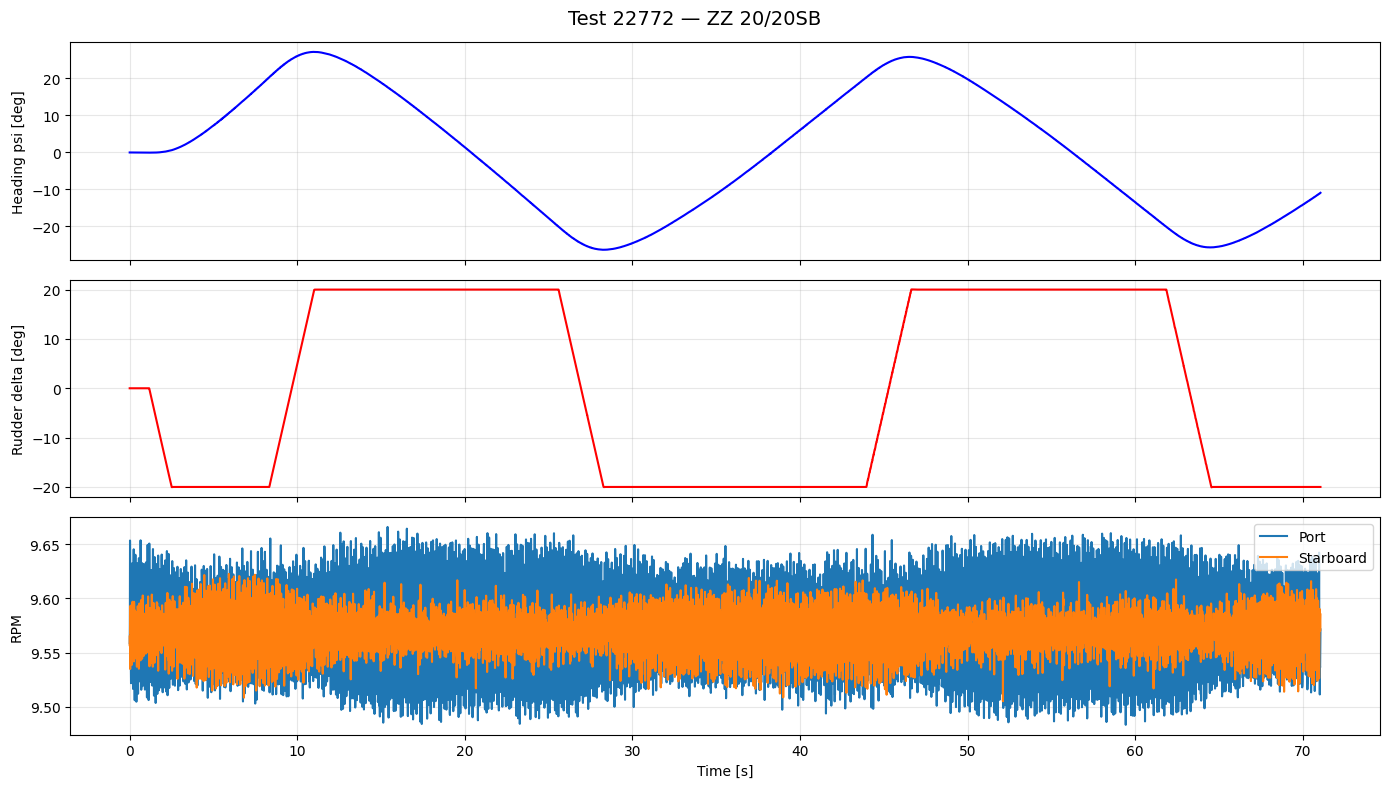

In [18]:
# Pick a zigzag test to examine in detail
zz_ids = [tid for tid in runs if runs_meta.loc[int(tid), "test_type"] == "zigzag"]

for tid in zz_ids:
    df = runs[tid]
    meta = runs_meta.loc[int(tid)]

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"Test {tid} — {meta['comment']}", fontsize=14)

    # Heading
    axes[0].plot(df["t"], np.degrees(df["psi"]), "b-")
    axes[0].set_ylabel("Heading psi [deg]")
    axes[0].grid(True, alpha=0.3)

    # Rudder angle
    axes[1].plot(df["t"], np.degrees(df["delta"]), "r-")
    axes[1].set_ylabel("Rudder delta [deg]")
    axes[1].grid(True, alpha=0.3)

    # Propeller RPM (port & starboard)
    axes[2].plot(df["t"], df["Prop/PS/Rpm"], label="Port")
    axes[2].plot(df["t"], df["Prop/SB/Rpm"], label="Starboard")
    axes[2].set_ylabel("RPM")
    axes[2].set_xlabel("Time [s]")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### 3c. Turning Circle Test

At reference speed, the rudder is set to a fixed angle and the ship traces a circle.


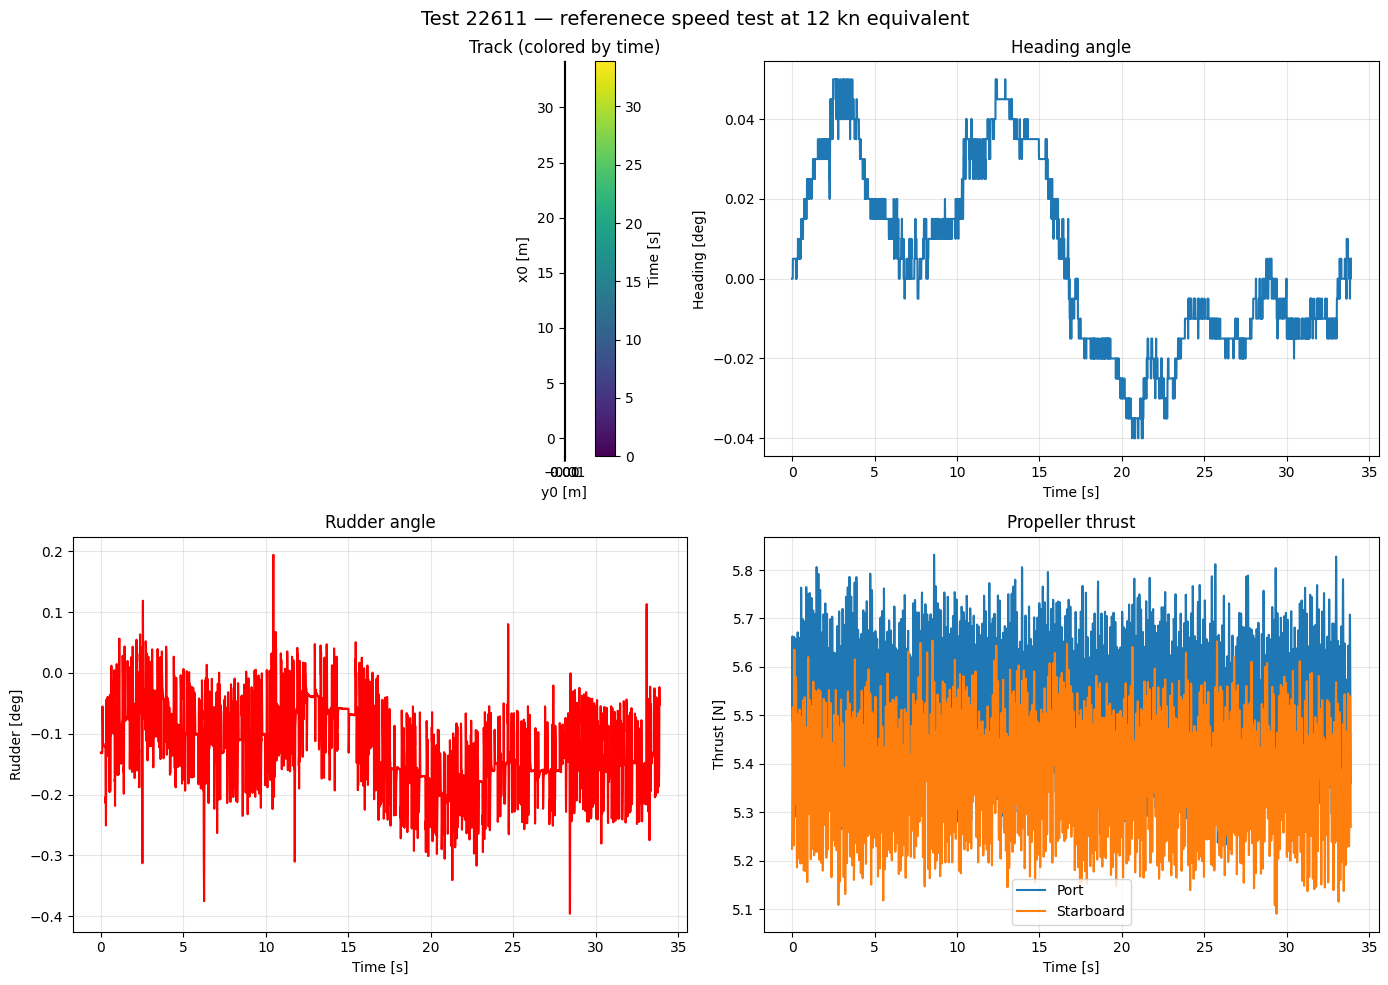

In [29]:
# Pick the 12 knot reference speed test
tid = "22611"
if tid in runs:
    df = runs[tid]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # fig.suptitle(f"Test {tid} — Turning circle at 12 kn equivalent", fontsize=14)
    fig.suptitle(f"Test {tid} — referenece speed test at 12 kn equivalent", fontsize=14)

    # Track
    ax = axes[0, 0]
    sc = ax.scatter(df["y0"], df["x0"], c=df["t"], cmap="viridis", s=1)
    plt.colorbar(sc, ax=ax, label="Time [s]")
    ax.set_xlabel("y0 [m]")
    ax.set_ylabel("x0 [m]")
    ax.set_title("Track (colored by time)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    # Heading
    ax = axes[0, 1]
    ax.plot(df["t"], np.degrees(df["psi"]))
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Heading [deg]")
    ax.set_title("Heading angle")
    ax.grid(True, alpha=0.3)

    # Rudder
    ax = axes[1, 0]
    ax.plot(df["t"], np.degrees(df["delta"]), "r-")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Rudder [deg]")
    ax.set_title("Rudder angle")
    ax.grid(True, alpha=0.3)

    # Thrust
    ax = axes[1, 1]
    ax.plot(df["t"], df["Prop/PS/Thrust"], label="Port")
    ax.plot(df["t"], df["Prop/SB/Thrust"], label="Starboard")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Thrust [N]")
    ax.set_title("Propeller thrust")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Pipeline Output: Kalman-Filtered Data

After running `--pipeline wpcc`, the Extended Kalman Filter produces smoothed state estimates with velocities (u, v, r) that aren't directly measured.


In [20]:
# Check what pipeline outputs exist
smooth_files = (
    sorted([f for f in os.listdir(PRIMARY) if f.endswith(".ek_smooth.csv")])
    if os.path.exists(PRIMARY)
    else []
)
lowpass_files = (
    sorted([f for f in os.listdir(INTERMEDIATE) if f.endswith(".lowpass.csv")])
    if os.path.exists(INTERMEDIATE)
    else []
)

if smooth_files:
    print("Smoothed data files (EKF output):")
    for f in smooth_files:
        print(f"  {f}")
else:
    print("No smoothed data found. Run the pipeline first:")
    print("  PYTHONPATH=src:$PYTHONPATH python3 -m wPCC_pipeline --pipeline wpcc")

Smoothed data files (EKF output):
  wpcc.initial.22611.ek_smooth.csv
  wpcc.initial.22635.ek_smooth.csv
  wpcc.initial.22639.ek_smooth.csv
  wpcc.initial.22770.ek_smooth.csv
  wpcc.initial.22772.ek_smooth.csv
  wpcc.initial.22773.ek_smooth.csv
  wpcc.initial.joined.ek_smooth.csv
  wpcc.updated.22611.ek_smooth.csv
  wpcc.updated.22635.ek_smooth.csv
  wpcc.updated.22639.ek_smooth.csv
  wpcc.updated.22770.ek_smooth.csv
  wpcc.updated.22772.ek_smooth.csv
  wpcc.updated.22773.ek_smooth.csv
  wpcc.updated.joined.ek_smooth.csv


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


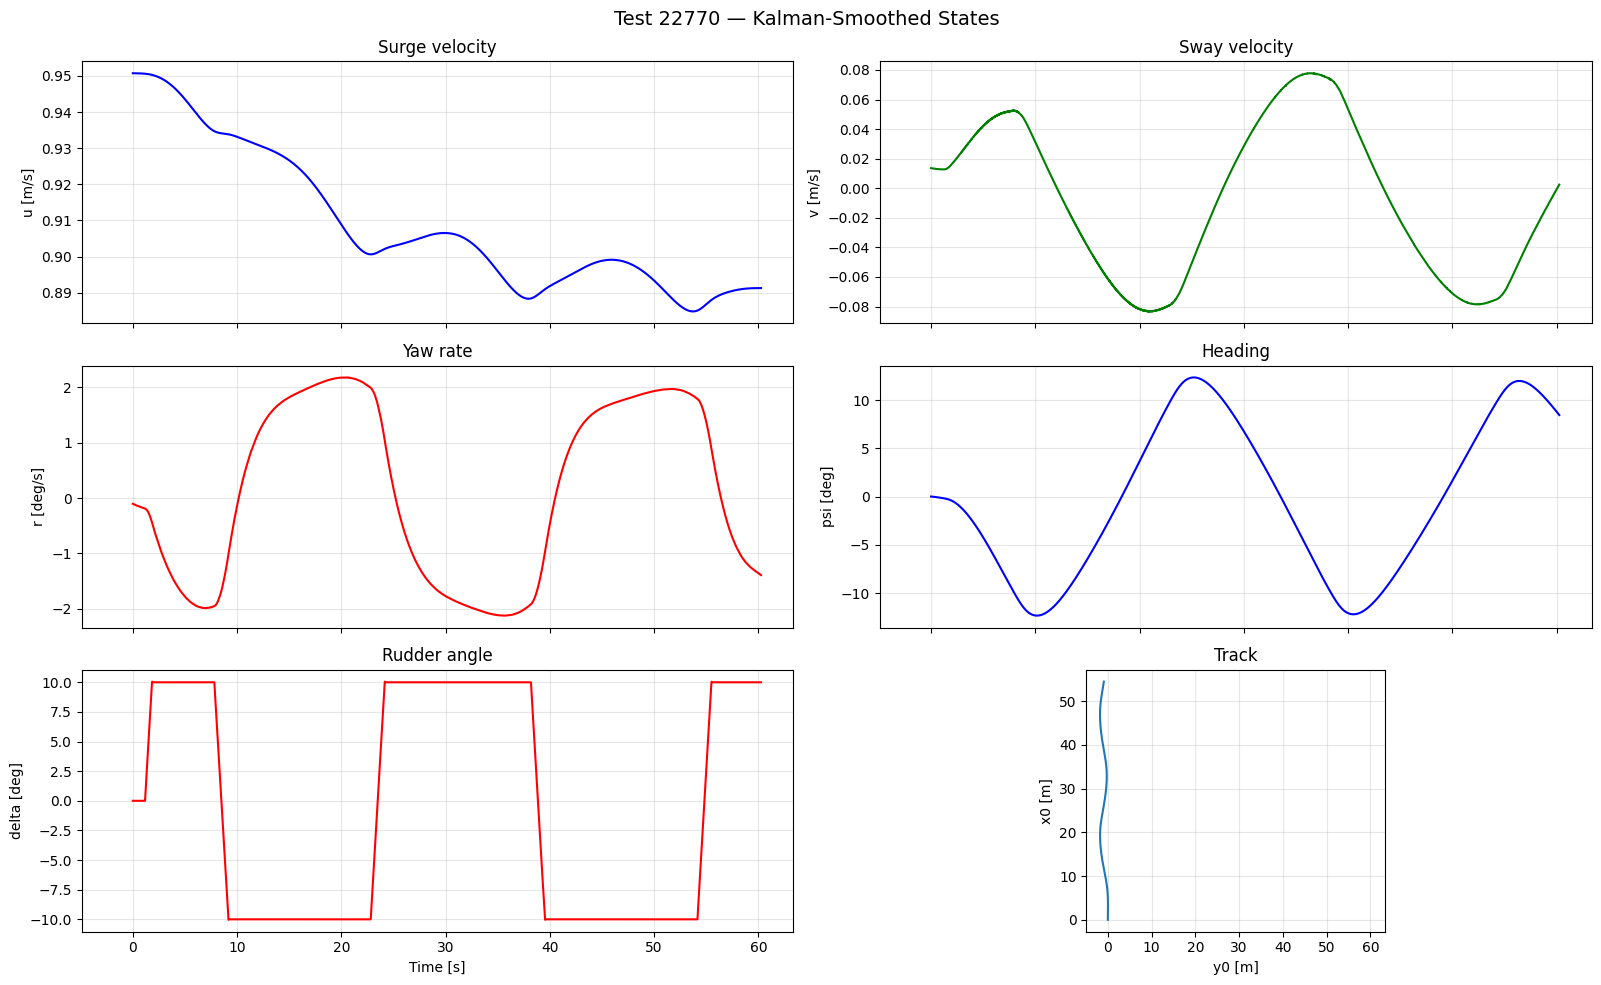

In [21]:
# Load smoothed data for one test
tid = "22770"  # ZZ 10/10
smooth_path = os.path.join(PRIMARY, f"wpcc.initial.{tid}.ek_smooth.csv")

if os.path.exists(smooth_path):
    df_smooth = pd.read_csv(smooth_path, index_col=0)

    fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
    fig.suptitle(f"Test {tid} — Kalman-Smoothed States", fontsize=14)

    t = df_smooth.index

    # Surge velocity
    axes[0, 0].plot(t, df_smooth["u"], "b-")
    axes[0, 0].set_ylabel("u [m/s]")
    axes[0, 0].set_title("Surge velocity")
    axes[0, 0].grid(True, alpha=0.3)

    # Sway velocity
    axes[0, 1].plot(t, df_smooth["v"], "g-")
    axes[0, 1].set_ylabel("v [m/s]")
    axes[0, 1].set_title("Sway velocity")
    axes[0, 1].grid(True, alpha=0.3)

    # Yaw rate
    axes[1, 0].plot(t, np.degrees(df_smooth["r"]), "r-")
    axes[1, 0].set_ylabel("r [deg/s]")
    axes[1, 0].set_title("Yaw rate")
    axes[1, 0].grid(True, alpha=0.3)

    # Heading
    axes[1, 1].plot(t, np.degrees(df_smooth["psi"]), "b-")
    axes[1, 1].set_ylabel("psi [deg]")
    axes[1, 1].set_title("Heading")
    axes[1, 1].grid(True, alpha=0.3)

    # Rudder angle
    axes[2, 0].plot(t, np.degrees(df_smooth["delta"]), "r-")
    axes[2, 0].set_ylabel("delta [deg]")
    axes[2, 0].set_xlabel("Time [s]")
    axes[2, 0].set_title("Rudder angle")
    axes[2, 0].grid(True, alpha=0.3)

    # Track
    axes[2, 1].plot(df_smooth["y0"], df_smooth["x0"])
    axes[2, 1].set_xlabel("y0 [m]")
    axes[2, 1].set_ylabel("x0 [m]")
    axes[2, 1].set_title("Track")
    axes[2, 1].set_aspect("equal")
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f"Smoothed data not found: {smooth_path}")
    print("Run the pipeline first.")

## 5. Compare Raw vs Low-Pass vs Kalman-Smoothed

The pipeline applies two levels of filtering:

1. **Low-pass filter** — removes high-frequency noise from position/heading
2. **Extended Kalman Filter** — estimates velocities and accelerations, smooths everything consistently


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


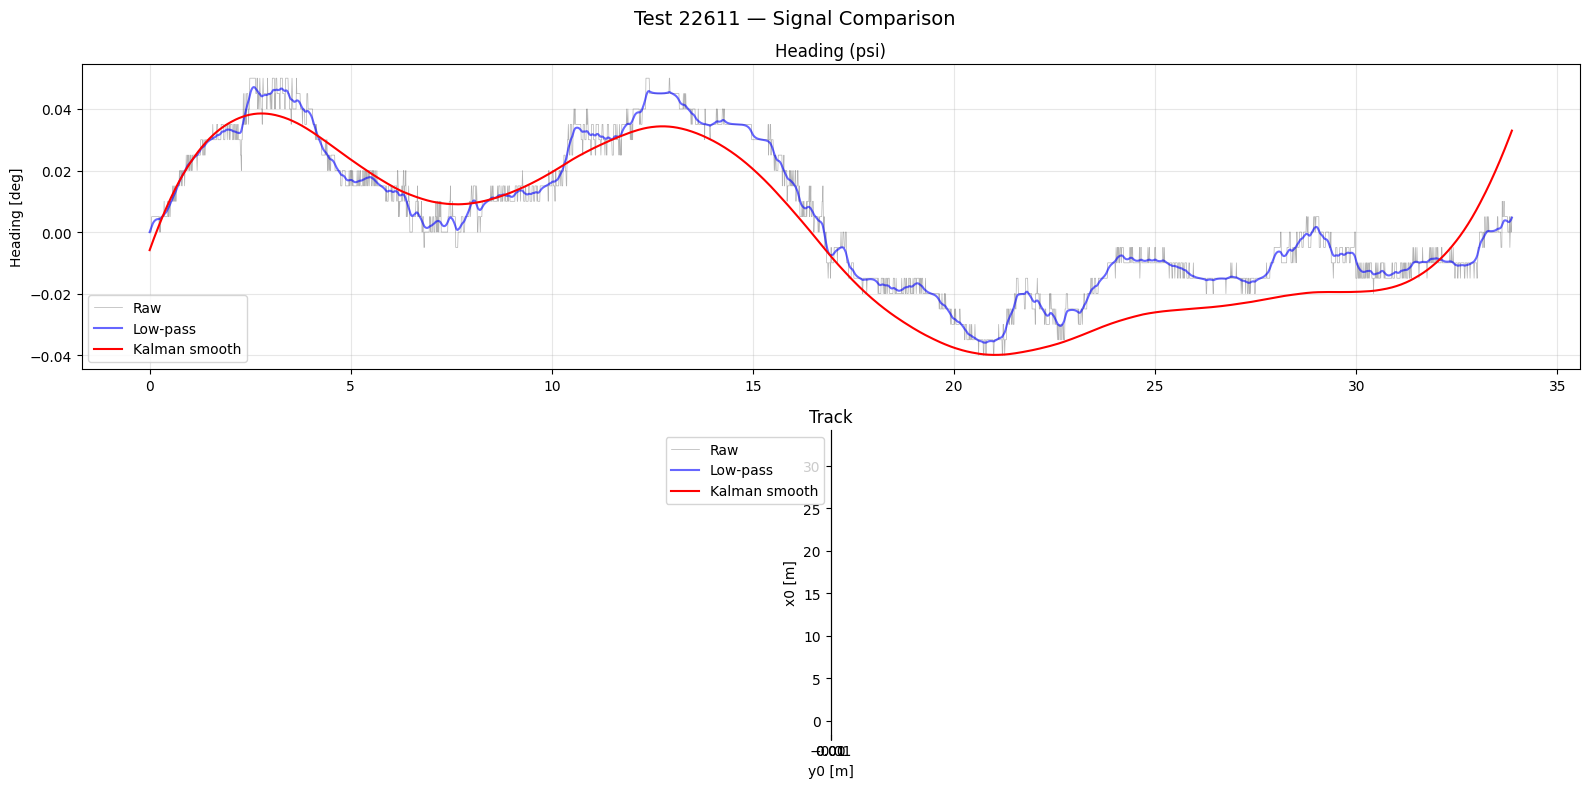

In [22]:
tid = "22611"

raw_path = os.path.join(RAW, f"{tid}.csv")
lowpass_path = os.path.join(INTERMEDIATE, f"wpcc.{tid}.lowpass.csv")
smooth_path = os.path.join(PRIMARY, f"wpcc.initial.{tid}.ek_smooth.csv")

have_all = all(os.path.exists(p) for p in [raw_path, lowpass_path, smooth_path])

if have_all:
    df_raw = pd.read_csv(raw_path)
    df_raw["t"] = df_raw["time"] - df_raw["time"].iloc[0]
    df_lp = pd.read_csv(lowpass_path)
    df_lp["t"] = (
        df_lp["time"] - df_lp["time"].iloc[0]
        if "time" in df_lp.columns
        else range(len(df_lp))
    )
    df_sm = pd.read_csv(smooth_path, index_col=0)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle(f"Test {tid} — Signal Comparison", fontsize=14)

    # Heading comparison
    ax = axes[0]
    ax.plot(
        df_raw["t"],
        np.degrees(df_raw["psi"]),
        "k-",
        alpha=0.3,
        label="Raw",
        linewidth=0.5,
    )
    if "psi" in df_lp.columns:
        ax.plot(df_lp["t"], np.degrees(df_lp["psi"]), "b-", alpha=0.6, label="Low-pass")
    ax.plot(df_sm.index, np.degrees(df_sm["psi"]), "r-", label="Kalman smooth")
    ax.set_ylabel("Heading [deg]")
    ax.set_title("Heading (psi)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Position comparison
    ax = axes[1]
    ax.plot(df_raw["y0"], df_raw["x0"], "k-", alpha=0.3, label="Raw", linewidth=0.5)
    if "x0" in df_lp.columns:
        ax.plot(df_lp["y0"], df_lp["x0"], "b-", alpha=0.6, label="Low-pass")
    ax.plot(df_sm["y0"], df_sm["x0"], "r-", label="Kalman smooth")
    ax.set_xlabel("y0 [m]")
    ax.set_ylabel("x0 [m]")
    ax.set_title("Track")
    ax.legend()
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    missing = [p for p in [lowpass_path, smooth_path] if not os.path.exists(p)]
    print(f"Missing files (run pipeline first): {missing}")

## 6. Using the Kedro Catalog

For full access to all pipeline datasets (including in-memory ones), use the Kedro catalog.
This is how the existing project notebooks work.


In [23]:
import sys

sys.path.insert(0, os.path.join(ROOT, "src"))

try:
    from kedro.framework.session import KedroSession
    from kedro.framework.startup import bootstrap_project
    from pathlib import Path

    project_path = Path(ROOT) if ROOT else Path(".")
    bootstrap_project(project_path)
    session = KedroSession.create(project_path=project_path)
    context = session.load_context()
    catalog = context.catalog

    print("Kedro catalog loaded successfully!")
    print(f"\nAvailable datasets ({len(catalog.list())} total):")
    # Show a sample
    for name in sorted(catalog.list())[:20]:
        print(f"  {name}")
    print(f"  ... and {len(catalog.list()) - 20} more")
except Exception as e:
    print(f"Could not load Kedro catalog: {e}")
    print(
        "This is fine — you can still load data directly from CSV files as shown above."
    )

2026-05-20 09:40:37,424 - kedro.framework.session.store - INFO - `read()` not implemented for `SQLiteStore`. Assuming empty store.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/kedro/framework/context/context.py:488: UserWarning: Credentials not found in your Kedro project config.
No files found in ['/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/base', '/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/local'] matching the glob pattern(s): ['credentials*', 'credentials*/**', '**/credentials*']
  warn(f"Credentials not found in your Kedro project config.\n{str(exc)}")


Kedro catalog loaded successfully!

Available datasets (2134 total):
  LNG.db_runs
  LNG.run_yml
  LNG_tanker.db_runs
  LNG_tanker.run_yml
  USV.added_masses
  USV.initial.joined.data_ek_smooth
  USV.initial.turnningdata_xy.data_ek_filter
  USV.initial.turnningdata_xy.data_ek_smooth
  USV.initial.turnningdata_xy.x0
  USV.initial.vmm_abkowitz.joined.derivatives
  USV.initial.vmm_abkowitz.joined.model
  USV.initial.vmm_abkowitz.joined.plot_N
  USV.initial.vmm_abkowitz.joined.plot_X
  USV.initial.vmm_abkowitz.joined.plot_Y
  USV.initial.vmm_abkowitz.joined.regression
  USV.initial.vmm_abkowitz.joined.summary_N
  USV.initial.vmm_abkowitz.joined.summary_X
  USV.initial.vmm_abkowitz.joined.summary_Y
  USV.initial.vmm_abkowitz.joined.turnningdata_xy.data_damping_forces
  USV.initial.vmm_abkowitz.joined.turnningdata_xy.data_online_predict
  ... and 2114 more


In [24]:
# Example: load data via catalog
try:
    ship = catalog.load("wpcc.ship_data")
    added_masses = catalog.load("wpcc.added_masses")
    print("Ship data loaded via catalog:")
    print(f"  Length: {ship['L']:.3f} m, Mass: {ship['m']:.1f} kg")
    print(f"\nAdded masses:")
    for k, v in added_masses.items():
        print(f"  {k}: {v}")
except NameError:
    print("Catalog not available — see cell above.")
except Exception as e:
    print(f"Error loading: {e}")

2026-05-20 09:40:38,106 - kedro.io.data_catalog - INFO - Loading data from `wpcc.ship_data` (YAMLDataSet)...
2026-05-20 09:40:38,113 - kedro.io.data_catalog - INFO - Loading data from `wpcc.added_masses` (YAMLDataSet)...
Ship data loaded via catalog:
  Length: 5.015 m, Mass: 441.0 kg

Added masses:
  Nrdot: -0.00029867482773178765
  Nvdot: -0.00012825440172375716
  Xudot: 0.00017880704448812042
  Yrdot: -0.00030313777458141895
  Yvdot: -0.006109387408263365


## 7. Understanding the Physical Model

The pipeline fits **Vessel Manoeuvring Models (VMMs)** — equations that relate ship velocities to hydrodynamic forces:

- **X** (surge force): drives the ship forward/backward
- **Y** (sway force): pushes the ship sideways
- **N** (yaw moment): rotates the ship

Each force is a polynomial function of the velocities (u, v, r) and rudder angle (delta).
The regression pipeline fits the polynomial coefficients ("hydrodynamic derivatives") from the test data.


In [25]:
# Load the VMM model objects
import dill

vmm_path = os.path.join(ROOT, "data/05_model_input/vmm_linear.pkl")
if os.path.exists(vmm_path):
    with open(vmm_path, "rb") as f:
        vmm = dill.load(f)

    print(f"VMM type: {type(vmm).__name__}")
    print(f"\nAttributes: {[a for a in dir(vmm) if not a.startswith('_')][:15]}")

    # Show the symbolic equations if available
    if hasattr(vmm, "X_eq"):
        print(f"\nSurge equation (X):")
        print(f"  {vmm.X_eq}")
    if hasattr(vmm, "Y_eq"):
        print(f"\nSway equation (Y):")
        print(f"  {vmm.Y_eq}")
    if hasattr(vmm, "N_eq"):
        print(f"\nYaw equation (N):")
        print(f"  {vmm.N_eq}")
else:
    print(f"VMM not found at {vmm_path}")
    print(
        "Run the pipeline first (the vessel_manoeuvring_models sub-pipeline creates these)."
    )

VMM type: VMM

Attributes: ['N_eq', 'N_eq_separated', 'N_qs_eq', 'X_eq', 'X_eq_separated', 'X_qs_eq', 'Y_eq', 'Y_eq_separated', 'Y_qs_eq', 'separated_equation']

Surge equation (X):
  Eq(\dot{u}*m, X_{\dot{u}}*\dot{u} + X_{delta}*delta + X_{r}*r + X_{u}*u + X_{v}*v)

Sway equation (Y):
  Eq(m*(U*r + \dot{r}*x_G + \dot{v}), Y_{\dot{r}}*\dot{r} + Y_{\dot{v}}*\dot{v} + Y_{delta}*delta + Y_{r}*r + Y_{u}*u + Y_{v}*v)

Yaw equation (N):
  Eq(I_z*\dot{r} + m*x_G*(U*r + \dot{v}), N_{\dot{r}}*\dot{r} + N_{\dot{v}}*\dot{v} + N_{delta}*delta + N_{r}*r + N_{u}*u + N_{v}*v)


## 8. Joined Data — All Runs Combined

The pipeline joins multiple test runs into a single dataset for regression. This gives the model more data to fit from.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


Joined dataset: 37696 samples, 35 columns
Columns: ['x0', 'y0', 'psi', 'u', 'v', 'r', 'Prop/SB/Thrust', 'v1d', 'Hull/Acc/Z1', 'Hull/Acc/Z2', 'z0', 'r1d', 'Prop/SB/Torque', 'u1d', 'V', 'Prop/SB/Rpm', 'Hull/Acc/Y2', 'delta', 'U', 'pitch', 'Prop/PS/Thrust', 'thrust', 'Hull/Acc/X1', 'roll', 'Prop/PS/Torque', 'Hull/Acc/Y1', 'Hull/Acc/Z3', 'Prop/PS/Rpm', 'time', 'id', 'Fan/Fore/CalcAngle', 'Fan/Aft/CalcAngle', 'Wind/Course', 'Wind/CourseTreshold', 'Wind/Enable']


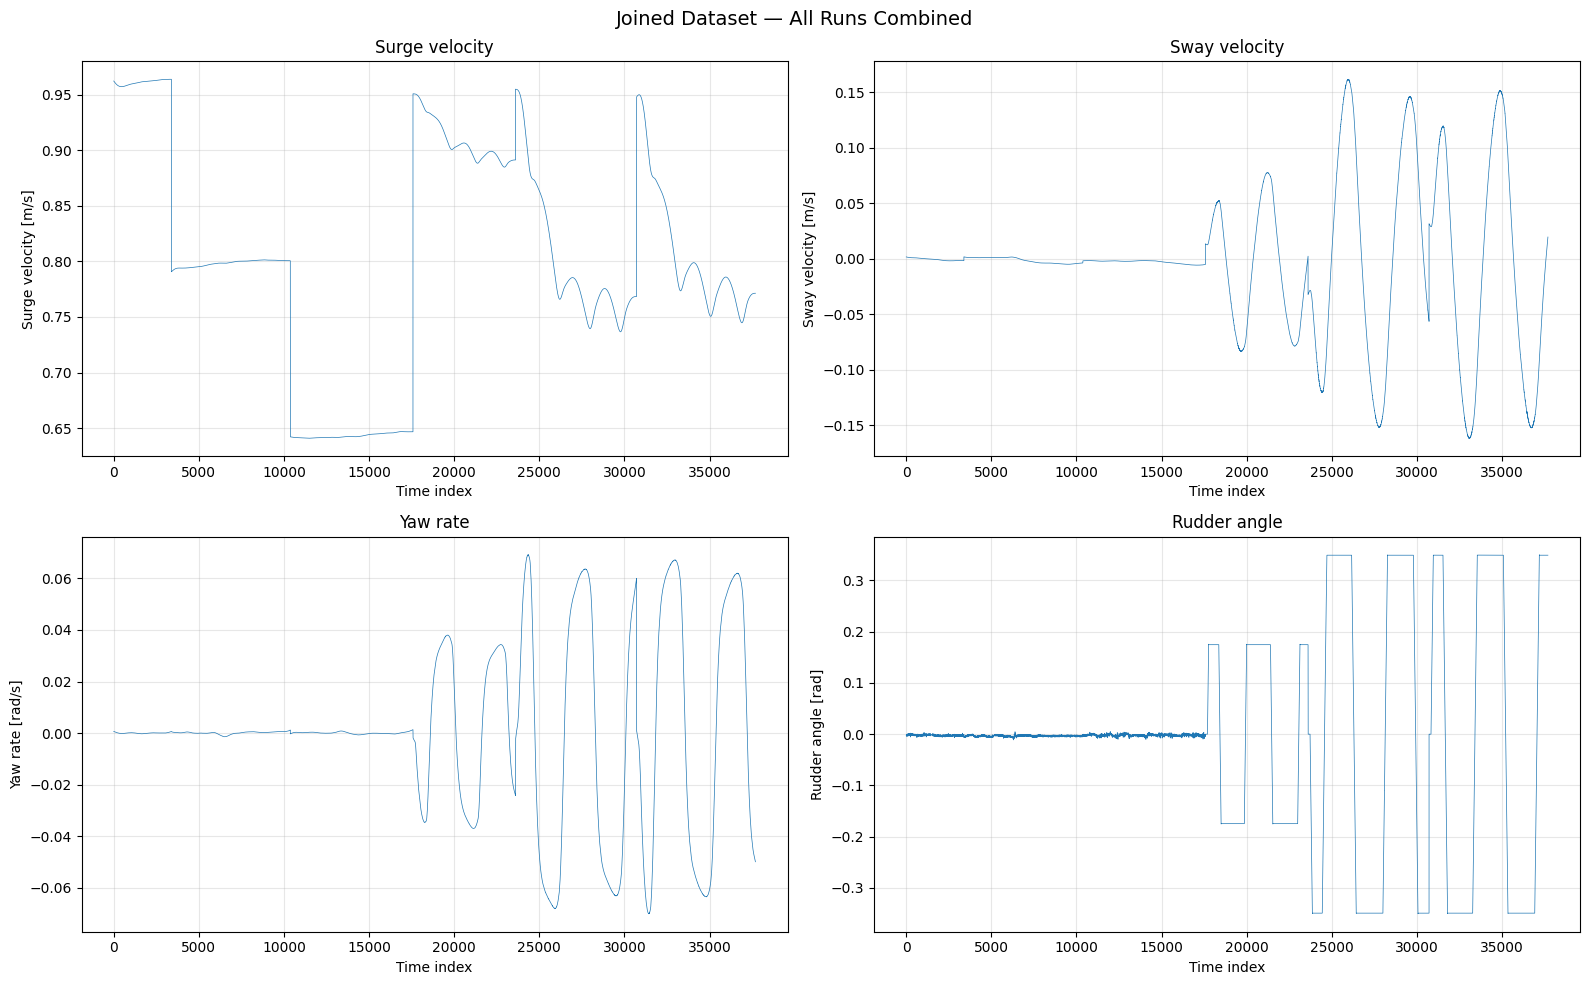

In [26]:
joined_path = os.path.join(PRIMARY, "wpcc.initial.joined.ek_smooth.csv")

if os.path.exists(joined_path):
    df_joined = pd.read_csv(joined_path, index_col=0)
    print(f"Joined dataset: {len(df_joined)} samples, {len(df_joined.columns)} columns")
    print(f"Columns: {list(df_joined.columns)}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Joined Dataset — All Runs Combined", fontsize=14)

    t = df_joined.index

    for ax, col, label, unit in [
        (axes[0, 0], "u", "Surge velocity", "m/s"),
        (axes[0, 1], "v", "Sway velocity", "m/s"),
        (axes[1, 0], "r", "Yaw rate", "rad/s"),
        (axes[1, 1], "delta", "Rudder angle", "rad"),
    ]:
        ax.plot(t, df_joined[col], linewidth=0.5)
        ax.set_ylabel(f"{label} [{unit}]")
        ax.set_xlabel("Time index")
        ax.set_title(label)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Joined data not found — run the pipeline first.")

## Next Steps

After the pipeline completes fully, you can:

1. **Examine regression results** — fitted hydrodynamic derivatives in `data/06_models/`
2. **Compare VMMs** — Abkowitz (nonlinear) vs Linear vs Martins Simple
3. **Run predictions** — simulate trajectories and compare with measurements
4. **Check existing notebooks** — `notebooks/06.01_accuracy.ipynb`, `notebooks/08.01_cross_validation.ipynb`
5. **Modify parameters** — tune EKF in `conf/base/parameters/extended_kalman.yml`

See `SETUP.md` for full documentation.
